# Import Modules

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read CSV

In [122]:
pd.set_option("display.max_columns", 30)

In [123]:
df = pd.read_csv("../csv_files/hr_job_placement_dataset_cleaned.csv")

In [124]:
df.head()

,Unnamed: 0,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,internship_experience,years_of_experience,career_switch_willingness,...,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status,exp_category,academic_score,academic_perfomance,skill_level,interview_score,interview_performance
0,0,27,Male,65.062,83.843,75.857,Computer Science,58.222,89.566,64.474,79.549,2,No,1,Willing,...,Tier 3,Not Matched,Medium,Not Required,15,No,18,Not Willing,Not Placed,Junior,74.920667,Good,High,NaN,Excellent
1,1,24,Male,67.886,64.973,73.094,Electronics,71.928,54.592,61.077,73.316,1,Yes,0,Not Willing,...,Tier 1,Matched,High,Required,0,No,3,Not Willing,Not Placed,Fresher,68.651000,Average,Medium,NaN,Excellent
2,2,33,Female,73.892,68.834,90.196,Information Technology,72.445,58.587,79.495,75.467,1,Yes,1,Willing,...,Tier 3,Not Matched,Low,Not Required,0,No,3,Not Willing,Placed,Junior,77.640667,Good,High,NaN,Excellent
3,3,31,Male,74.146,76.255,75.587,Mechanical,78.856,61.022,53.740,73.676,2,No,0,Not Willing,...,Tier 2,Matched,Low,Not Required,0,Yes,6,Willing,Not Placed,Fresher,75.329333,Good,Medium,NaN,Excellent
4,4,28,Male,60.476,65.786,80.801,Information Technology,68.287,65.714,61.438,88.995,1,No,0,Willing,...,Tier 2,Matched,Medium,Not Required,0,No,3,Willing,Not Placed,Fresher,69.021000,Average,High,NaN,Excellent


In [125]:
df.shape

(50000, 33)

In [126]:
df_copy = df.copy()

# Exploratory Data Analysis

## Interview score vs job acceptance

In [127]:
df_copy["interview_score"] = df_copy[['technical_score', 'aptitude_score', 'communication_score']].mean(axis=1)

In [128]:
df_copy.head()

,Unnamed: 0,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,internship_experience,years_of_experience,career_switch_willingness,...,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status,exp_category,academic_score,academic_perfomance,skill_level,interview_score,interview_performance
0,0,27,Male,65.062,83.843,75.857,Computer Science,58.222,89.566,64.474,79.549,2,No,1,Willing,...,Tier 3,Not Matched,Medium,Not Required,15,No,18,Not Willing,Not Placed,Junior,74.920667,Good,High,70.754000,Excellent
1,1,24,Male,67.886,64.973,73.094,Electronics,71.928,54.592,61.077,73.316,1,Yes,0,Not Willing,...,Tier 1,Matched,High,Required,0,No,3,Not Willing,Not Placed,Fresher,68.651000,Average,Medium,62.532333,Excellent
2,2,33,Female,73.892,68.834,90.196,Information Technology,72.445,58.587,79.495,75.467,1,Yes,1,Willing,...,Tier 3,Not Matched,Low,Not Required,0,No,3,Not Willing,Placed,Junior,77.640667,Good,High,70.175667,Excellent
3,3,31,Male,74.146,76.255,75.587,Mechanical,78.856,61.022,53.740,73.676,2,No,0,Not Willing,...,Tier 2,Matched,Low,Not Required,0,Yes,6,Willing,Not Placed,Fresher,75.329333,Good,Medium,64.539333,Excellent
4,4,28,Male,60.476,65.786,80.801,Information Technology,68.287,65.714,61.438,88.995,1,No,0,Willing,...,Tier 2,Matched,Medium,Not Required,0,No,3,Willing,Not Placed,Fresher,69.021000,Average,High,65.146333,Excellent


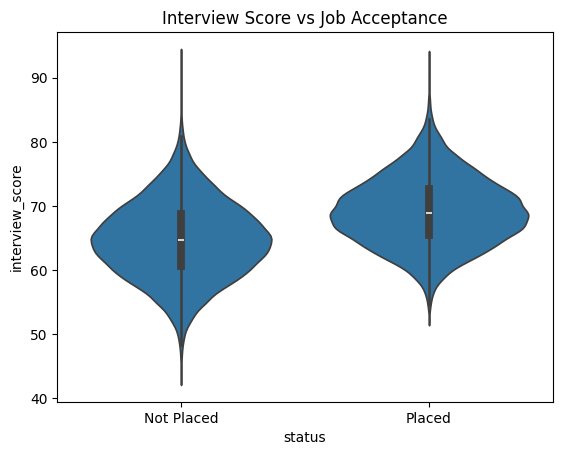

In [129]:
sns.violinplot(
    x="status",
    y="interview_score",
    data=df_copy
)

plt.title("Interview Score vs Job Acceptance")
plt.show()

- This plot shows that placed candidates achieved higher interview scores than non-placed candidates.

- Although some high-scoring candidates remained unplaced and some low-scoring candidates got placed, it shows that interview score is not the only requirement for job acceptance.

---

## Skills match percentage impact on placement

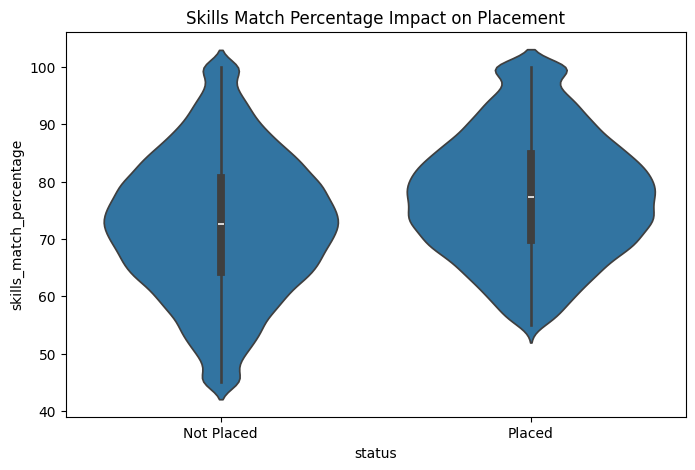

In [130]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x="status",
    y="skills_match_percentage",
    data=df_copy
)

plt.title("Skills Match Percentage Impact on Placement")

plt.show()

- This plot shows that placed candidates generally have higher skills match percentages than non-placed candidates.

- Although some high skill-match candidates remain unplaced and some lower skill-match candidates get placed.

---

## Company tier vs acceptance rate

In [131]:
company_percent = df.groupby("company_tier")["status"].value_counts(normalize=True).unstack()

In [132]:
company_percent

status,Not Placed,Placed
company_tier,,
Tier 1,0.700648,0.299352
Tier 2,0.695829,0.304171
Tier 3,0.694645,0.305355


<Axes: xlabel='company_tier'>

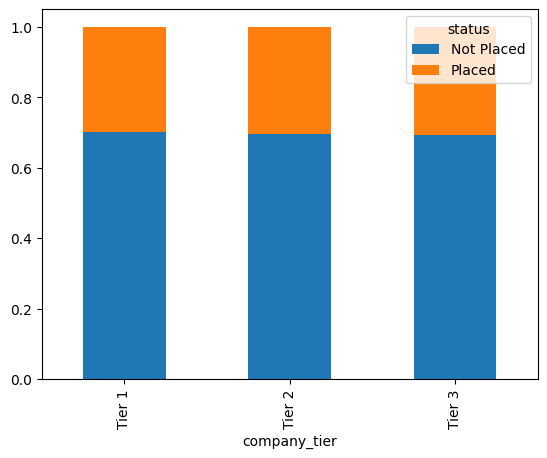

In [133]:
company_percent.plot(kind='bar', stacked=True)

<Axes: xlabel='status', ylabel='count'>

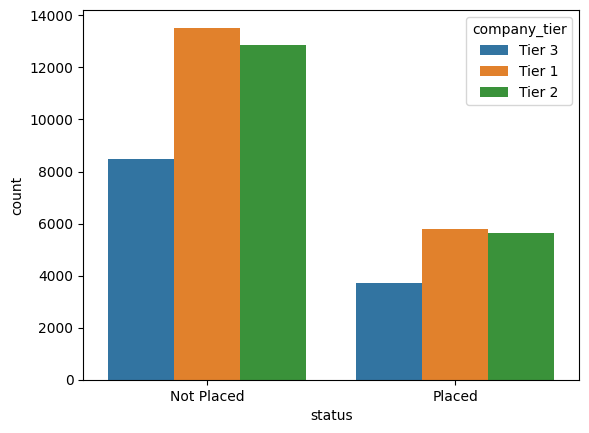

In [134]:
sns.countplot(
    data=df_copy,
    x="status",
    hue="company_tier"
)

- It shows that placement scceptance rate is nearly similar.

---

## Experience vs placement probability

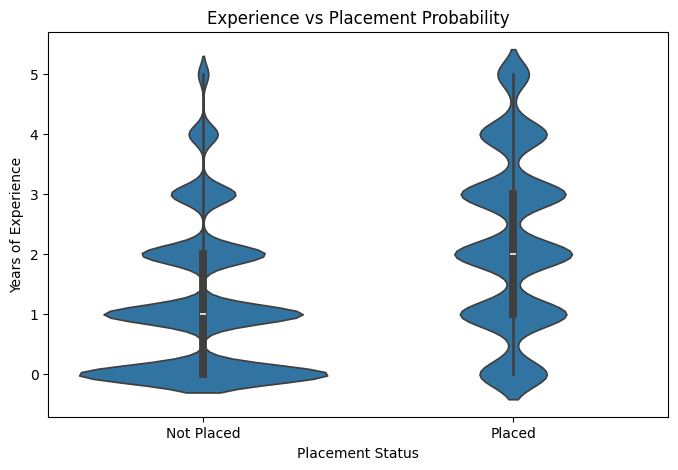

In [135]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x="status",
    y="years_of_experience",
    data=df
)

plt.title("Experience vs Placement Probability")
plt.xlabel("Placement Status")
plt.ylabel("Years of Experience")

plt.show()

<Axes: xlabel='status', ylabel='count'>

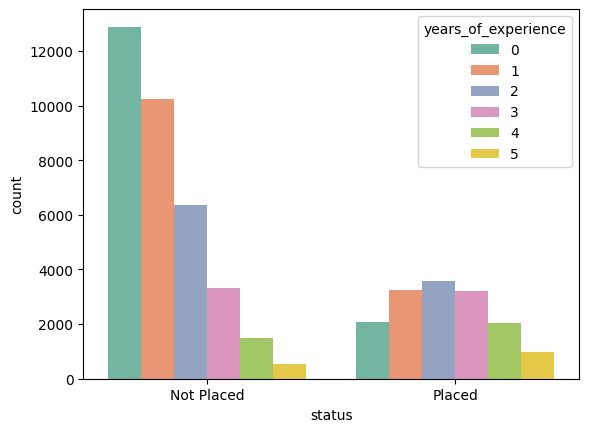

In [136]:
sns.countplot(
    data=df_copy,
    x="status",
    hue="years_of_experience",
    palette="Set2"
)

- Placed candidates are more conctrated around 1 - 3 years of experiencs.

- Non-Placed candidates are mostly concentrated around 0-1 years of experience.

---

## Competition level vs job acceptance

In [137]:
df["competition_level"].value_counts()

competition_level
Low       20841
Medium    19114
High      10045
Name: count, dtype: int64

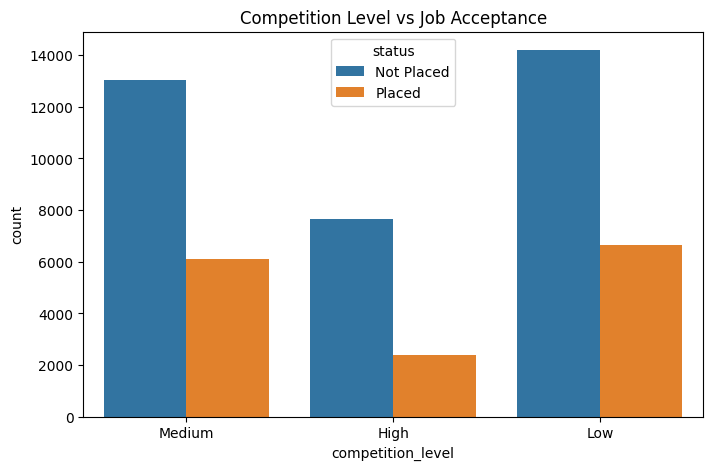

In [138]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_copy,
    x="competition_level",
    hue="status"
)

plt.title("Competition Level vs Job Acceptance")

plt.show()

- The plot shows that both `Low` and `Medium` competition levels have the highest number of placements.

- The `High` competition category has the lowest number of placements.

---

## Academic scores vs placement outcome

In [140]:
df_copy["academic_score"] = df[['ssc_percentage', 'hsc_percentage', 'degree_percentage']].mean(axis=1)

<Axes: xlabel='status', ylabel='academic_score'>

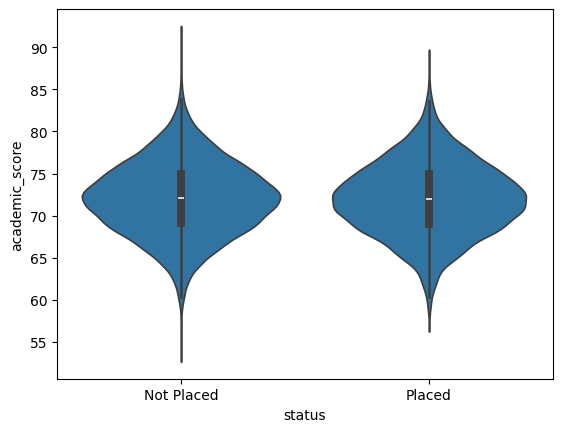

In [141]:
sns.violinplot(
    data=df_copy,
    x="status",
    y="academic_score"
)

- It shows that `Academic Score` has no Impact on Placement.

---

## Certification impact on job acceptance

<Axes: xlabel='status', ylabel='certifications_count'>

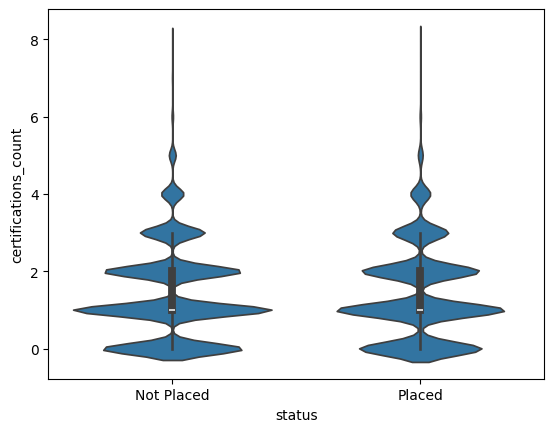

In [142]:
sns.violinplot(
    data=df_copy,
    x="status",
    y="certifications_count"
)

- It shows that `Certificate Count` has no Impact on Placement.

---